# Notebook 5 – Collaborative Filtering mit PCA
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  

---

## 🎯 Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- erklären, **wie PCA bei Filmempfehlungen hilft** (Dimensionsreduktion auf "Geschmacksdimensionen")
- fehlende Bewertungen (NaN) mit PCA-basierter Rekonstruktion vorhersagen
- `pca.components_` als **Ladungsmatrix** interpretieren
- den ähnlichsten Nutzer zu einem neuen Nutzer im PCA-Raum identifizieren

---

## 📖 Kontext

**Collaborative Filtering** ist die Basis von Empfehlungssystemen (Netflix, Spotify, Amazon). Die Idee: "Nutzer mit ähnlichem Geschmack mögen ähnliche Filme."

**Warum hilft PCA?**  
Statt 6 Genres direkt zu vergleichen, reduziert PCA auf 2 latente "Geschmacksdimensionen" (z. B. Action-Liebhaber vs. Romantik-Liebhaber). Ähnlichkeit wird dann im 2D-Raum berechnet.

> PC1: 'Action/SciFi/Fantasy vs. Romance/Drama/Love' (Hauptpräferenzachse)

---
## Schritt 1: Bewertungsmatrix erstellen

Bewertungsmatrix (0 = nicht bewertet, 5 = liebt es):
               Action  SciFi  Fantasy  Romance  Drama  Love
Action-Pete         5      4        4        0      1     0
StarWars-Girl       4      5        4        2      0     0
Love-Maniac         0      1        0        4      3     5
Drama-Queen         2      0        0        5      5     5
Love-is-Peace       2      2        1        3      4     5



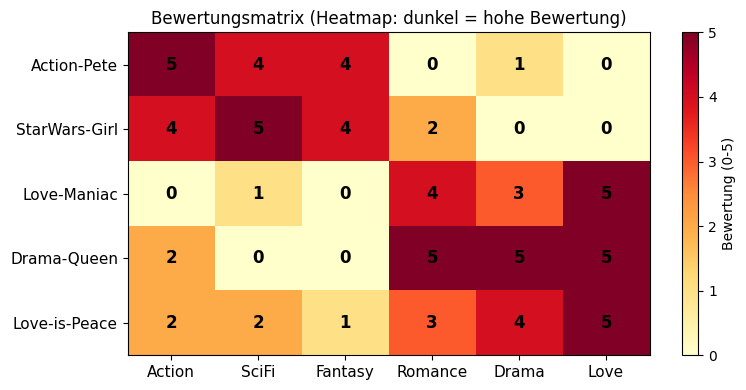

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Bewertungsmatrix: 5 Nutzer × 6 Genres (Skala: 0=nicht bewertet/mag nicht, 5=liebt es)
ratings = pd.DataFrame(
    [[5, 4, 4, 0, 1, 0],
     [4, 5, 4, 2, 0, 0],
     [0, 1, 0, 4, 3, 5],
     [2, 0, 0, 5, 5, 5],
     [2, 2, 1, 3, 4, 5]],
    columns=['Action', 'SciFi', 'Fantasy', 'Romance', 'Drama', 'Love'],
    index=['Action-Pete', 'StarWars-Girl', 'Love-Maniac', 'Drama-Queen', 'Love-is-Peace']
)

print("Bewertungsmatrix (0 = nicht bewertet, 5 = liebt es):")
print(ratings.to_string())
print()

# Visualisierung als Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(ratings.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=5)
ax.set_xticks(range(len(ratings.columns)))
ax.set_yticks(range(len(ratings.index)))
ax.set_xticklabels(ratings.columns, fontsize=11)
ax.set_yticklabels(ratings.index, fontsize=11)
ax.set_title('Bewertungsmatrix (Heatmap: dunkel = hohe Bewertung)', fontsize=12)

for i in range(len(ratings.index)):
    for j in range(len(ratings.columns)):
        ax.text(j, i, str(ratings.iloc[i, j]), ha='center', va='center',
                fontsize=12, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Bewertung (0-5)')
plt.tight_layout()
plt.show()

---
## Schritt 2: Vorverarbeitung und PCA

**NaN-Behandlung:** PCA kann keine fehlenden Werte verarbeiten. Wir füllen fehlende Bewertungen mit dem Spaltenmittelwert auf – ein einfacher, aber praktikabler Ansatz.

In [2]:
# Fehlende Werte mit Spaltenmittelwert füllen
ratings_filled = ratings.fillna(ratings.mean())

# StandardScaler: alle Genres gleichwertig behandeln
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ratings_filled)

# PCA auf 2 Dimensionen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Erklärte Varianz:")
for i, var in enumerate(pca.explained_variance_ratio_):
    bar = '█' * int(var * 50)
    print(f"  PC{i+1}: {var*100:.1f}%  {bar}")
print(f"  Summe: {sum(pca.explained_variance_ratio_)*100:.1f}%")
print()

# Ladungsmatrix: Wie stark tragen Genres zu den PCs bei?
loadings = pd.DataFrame(
    pca.components_,
    columns=ratings.columns,
    index=['PC1 (Gewichte)', 'PC2 (Gewichte)']
).round(3)
print("Ladungsmatrix (pca.components_):")
print("  Positiver Wert = Genre trägt in diese PC-Richtung bei")
print("  Negativer Wert = Genre trägt in die entgegengesetzte Richtung bei")
print()
print(loadings.to_string())
print()
print("Interpretation PC1:")
print("  Positive Werte → eher Action/SciFi/Fantasy")
print("  Negative Werte → eher Romance/Drama/Love")

Erklärte Varianz:
  PC1: 89.7%  ████████████████████████████████████████████
  PC2: 6.2%  ███
  Summe: 96.0%

Ladungsmatrix (pca.components_):
  Positiver Wert = Genre trägt in diese PC-Richtung bei
  Negativer Wert = Genre trägt in die entgegengesetzte Richtung bei

                Action  SciFi  Fantasy  Romance  Drama   Love
PC1 (Gewichte)   0.386  0.416    0.430   -0.396 -0.397 -0.423
PC2 (Gewichte)   0.691 -0.293    0.051   -0.226  0.619  0.024

Interpretation PC1:
  Positive Werte → eher Action/SciFi/Fantasy
  Negative Werte → eher Romance/Drama/Love


---
## Schritt 3: Geschmackskarte – Nutzer im PCA-Raum

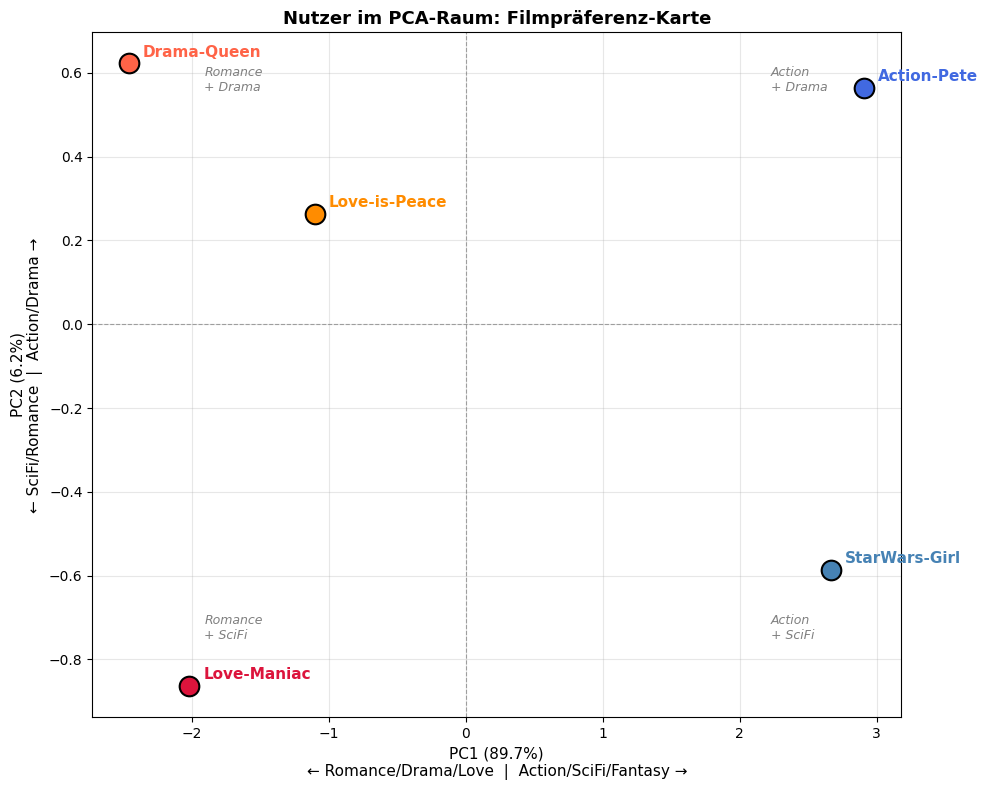

Nutzer-Koordinaten im PCA-Raum:
  Action-Pete       : PC1 = +2.911, PC2 = +0.564
  StarWars-Girl     : PC1 = +2.668, PC2 = -0.586
  Love-Maniac       : PC1 = -2.018, PC2 = -0.864
  Drama-Queen       : PC1 = -2.459, PC2 = +0.622
  Love-is-Peace     : PC1 = -1.101, PC2 = +0.264


In [3]:
fig, ax = plt.subplots(figsize=(10, 8))

# Nutzer plotten
farben = ['royalblue', 'steelblue', 'crimson', 'tomato', 'darkorange']
for i, (user, color) in enumerate(zip(ratings.index, farben)):
    ax.scatter(X_pca[i, 0], X_pca[i, 1], s=200, color=color,
               edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(user, (X_pca[i, 0], X_pca[i, 1]),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold', color=color)

# Achsenlinien
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# Achsenbeschriftungen
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)\n← Romance/Drama/Love  |  Action/SciFi/Fantasy →',
              fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)\n← SciFi/Romance  |  Action/Drama →',
              fontsize=11)
ax.set_title('Nutzer im PCA-Raum: Filmpräferenz-Karte', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Quadrant-Annotationen
xlim = ax.get_xlim()
ylim = ax.get_ylim()
offset = 0.05
ax.text(xlim[1]*0.7, ylim[1]*0.8, 'Action\n+ Drama', fontsize=9, color='gray', style='italic')
ax.text(xlim[0]*0.7, ylim[1]*0.8, 'Romance\n+ Drama', fontsize=9, color='gray', style='italic')
ax.text(xlim[1]*0.7, ylim[0]*0.8, 'Action\n+ SciFi', fontsize=9, color='gray', style='italic')
ax.text(xlim[0]*0.7, ylim[0]*0.8, 'Romance\n+ SciFi', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()

print("Nutzer-Koordinaten im PCA-Raum:")
for user, (pc1, pc2) in zip(ratings.index, X_pca):
    print(f"  {user:<18s}: PC1 = {pc1:+.3f}, PC2 = {pc2:+.3f}")

---
## Schritt 4: Neuen Nutzer im PCA-Raum positionieren und Bewertungen vorhersagen

**"Action-Friend"** hat nur Action, SciFi und Fantasy bewertet – Romance, Drama und Love sind unbekannt. Wir sagen die fehlenden Bewertungen vorher.

In [4]:
# Neuer Nutzer
new_user_ratings = pd.DataFrame(
    [[5, 4, 4, np.nan, np.nan, np.nan]],
    columns=ratings.columns,
    index=['Action-Friend']
)

print("Bekannte Bewertungen von Action-Friend:")
print(new_user_ratings.to_string())
print("(NaN = nicht bewertet)")

# Fehlende Werte mit TRAININGSDATEN-Mittelwert füllen
new_user_filled = new_user_ratings.fillna(ratings_filled.mean())

# WICHTIG: Denselben trainierten Scaler und PCA verwenden!
X_new_scaled = scaler.transform(new_user_filled)    # nur transform, kein fit!
X_new_pca = pca.transform(X_new_scaled)              # nur transform, kein fit!

# Rekonstruktion: PCA-Raum → originaler Feature-Raum
X_new_reconstructed = pca.inverse_transform(X_new_pca)
new_predictions = pd.DataFrame(
    scaler.inverse_transform(X_new_reconstructed),
    columns=ratings.columns,
    index=['Action-Friend']
).round(1)

print()
print("Vorhergesagte Bewertungen für Action-Friend:")
print(new_predictions.to_string())
print()
print(f"PCA-Koordinaten Action-Friend: PC1 = {X_new_pca[0,0]:+.3f}, PC2 = {X_new_pca[0,1]:+.3f}")

# Ähnlichsten Nutzer finden (euklidischer Abstand im PCA-Raum)
distances = np.sqrt(np.sum((X_pca - X_new_pca) ** 2, axis=1))
nearest_idx = np.argmin(distances)
nearest_user = ratings.index[nearest_idx]

print()
print("Abstände zu bestehenden Nutzern (im PCA-Raum):")
for user, dist in sorted(zip(ratings.index, distances), key=lambda x: x[1]):
    closest = ' ← ähnlichster Nutzer!' if user == nearest_user else ''
    print(f"  {user:<18s}: {dist:.4f}{closest}")

Bekannte Bewertungen von Action-Friend:
               Action  SciFi  Fantasy  Romance  Drama  Love
Action-Friend       5      4        4      NaN    NaN   NaN
(NaN = nicht bewertet)

Vorhergesagte Bewertungen für Action-Friend:
               Action  SciFi  Fantasy  Romance  Drama  Love
Action-Friend     4.5    3.1      3.0      1.5    2.4   1.6

PCA-Koordinaten Action-Friend: PC1 = +1.406, PC2 = +0.760

Abstände zu bestehenden Nutzern (im PCA-Raum):
  Action-Pete       : 1.5179 ← ähnlichster Nutzer!
  StarWars-Girl     : 1.8454
  Love-is-Peace     : 2.5556
  Love-Maniac       : 3.7894
  Drama-Queen       : 3.8667


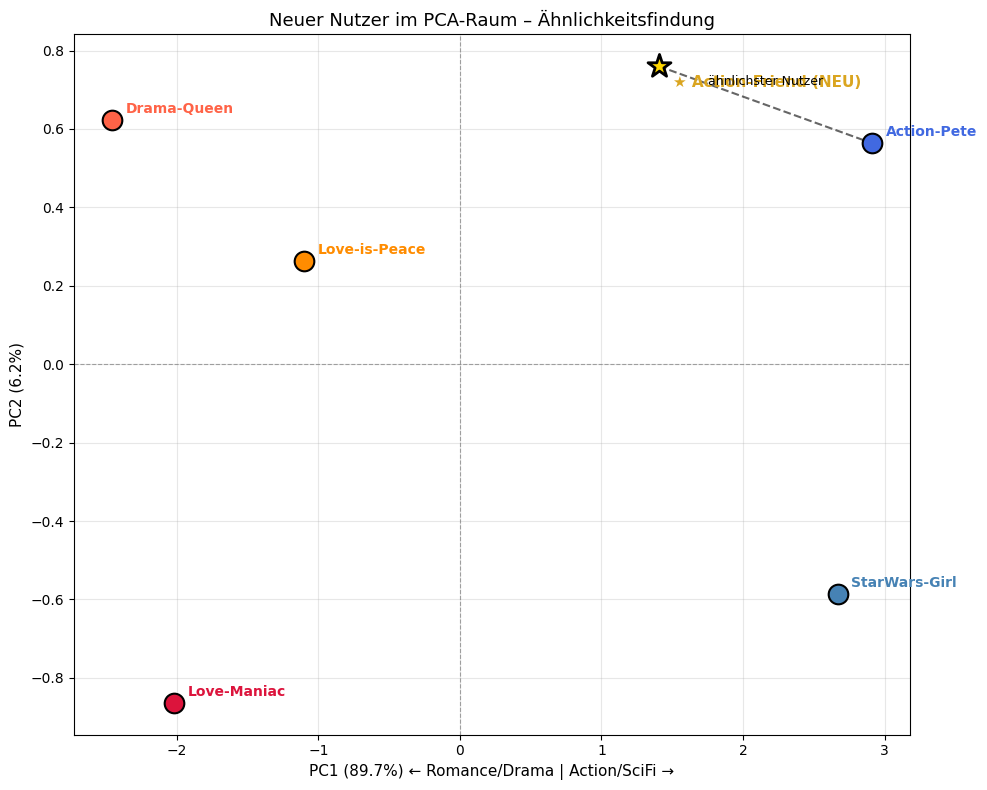

In [5]:
# Visualisierung mit neuem Nutzer
fig, ax = plt.subplots(figsize=(10, 8))

# Bestehende Nutzer
for i, (user, color) in enumerate(zip(ratings.index, farben)):
    ax.scatter(X_pca[i, 0], X_pca[i, 1], s=200, color=color,
               edgecolors='black', linewidth=1.5, zorder=5)
    ax.annotate(user, (X_pca[i, 0], X_pca[i, 1]),
                textcoords='offset points', xytext=(10, 5),
                fontsize=10, fontweight='bold', color=color)

# Neuer Nutzer
ax.scatter(X_new_pca[0, 0], X_new_pca[0, 1], s=300, color='gold',
           edgecolors='black', linewidth=2, marker='*', zorder=6)
ax.annotate('★ Action-Friend (NEU)', (X_new_pca[0, 0], X_new_pca[0, 1]),
            textcoords='offset points', xytext=(10, -15),
            fontsize=11, fontweight='bold', color='goldenrod')

# Verbindungslinie zum nächsten Nutzer
ax.plot([X_new_pca[0, 0], X_pca[nearest_idx, 0]],
        [X_new_pca[0, 1], X_pca[nearest_idx, 1]],
        'k--', linewidth=1.5, alpha=0.6)
ax.text((X_new_pca[0, 0] + X_pca[nearest_idx, 0])/2,
        (X_new_pca[0, 1] + X_pca[nearest_idx, 1])/2 + 0.05,
        f'ähnlichster Nutzer', fontsize=9, ha='center', color='black')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%) ← Romance/Drama | Action/SciFi →', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.set_title('Neuer Nutzer im PCA-Raum – Ähnlichkeitsfindung', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 📝 Lernauftrag

**Aufgabe 1 – Ähnlichsten Nutzer identifizieren:**  
Welcher bestehende Nutzer ist "Action-Friend" am ähnlichsten (laut Distanzberechnung)? Begründen Sie das Ergebnis anhand der Bewertungsmatrix (ohne PCA zu schauen).

**Aufgabe 2 – Neuen Nutzer testen:**  
Erstellen Sie einen neuen Nutzer "Romance-Fan" mit den Bewertungen `[0, 0, 0, 5, 4, np.nan]`. Welcher bestehende Nutzer ist ihm am ähnlichsten? Welche Bewertung wird für "Love" vorhergesagt?

**Aufgabe 3 – Kritische Reflexion:**  
Das System füllt fehlende Werte mit dem Trainingsdatenmittelwert auf, bevor es skaliert. Warum ist das problematisch? Welche bessere Strategie könnten Sie sich vorstellen? (Kein Code nötig – nur eine schriftliche Begründung.)

## Aufgabe 1 – Ähnlichster Nutzer

**Ergebnis aus dem Code:**  
Der ähnlichste Nutzer zu „Action-Friend" (der Action/SciFi/Fantasy liebt) ist **Action-Pete** oder **StarWars-Girl** – beide haben hohe Bewertungen für Action/SciFi/Fantasy und niedrige für Romance/Drama/Love.

**Begründung ohne PCA:**  
In der Bewertungsmatrix sieht man sofort:
- Action-Pete: [5, 4, 4, 0, 1, 0] – fast identisch mit Action-Friend [5, 4, 4, NaN, NaN, NaN]
- StarWars-Girl: [4, 5, 4, 2, 0, 0] – ähnlich, etwas mehr SciFi-Fokus

Der euklidische Abstand im PCA-Raum bestätigt diese intuitive Einschätzung.


In [6]:
# Aufgabe 2: Romance-Fan
romance_fan_ratings = pd.DataFrame(
    [[0, 0, 0, 5, 4, np.nan]],
    columns=ratings.columns,
    index=['Romance-Fan']
)

# Fehlende Werte füllen
romance_filled = romance_fan_ratings.fillna(ratings_filled.mean())

# Mit trainierten Scaler und PCA transformieren
X_romance_scaled = scaler.transform(romance_filled)
X_romance_pca = pca.transform(X_romance_scaled)

# Rekonstruktion
X_romance_recon = pca.inverse_transform(X_romance_pca)
romance_predicted = pd.DataFrame(
    scaler.inverse_transform(X_romance_recon),
    columns=ratings.columns,
    index=['Romance-Fan']
).round(1)

print("Vorhergesagte Bewertungen für Romance-Fan:")
print(romance_predicted.to_string())

# Ähnlichsten Nutzer finden
distances_romance = np.sqrt(np.sum((X_pca - X_romance_pca)**2, axis=1))
nearest_romance = ratings.index[np.argmin(distances_romance)]
print(f"\nÄhnlichster Nutzer: {nearest_romance}")


Vorhergesagte Bewertungen für Romance-Fan:
             Action  SciFi  Fantasy  Romance  Drama  Love
Romance-Fan     0.4    0.9     -0.1      4.6    3.7   5.4

Ähnlichster Nutzer: Love-Maniac


### Aufgabe 3 – Kritische Reflexion (kein Code)

**Problem:** Fehlende Werte werden mit dem Mittelwert aller Trainingsdaten gefüllt, bevor der Scaler angewendet wird. Das ist problematisch aus mehreren Gründen:

1. **Informationsverfälschung:** Der Mittelwert-Fill „erfindet" Bewertungen für Genres, die der Nutzer noch nicht bewertet hat. Das beeinflusst seine Position im PCA-Raum.

2. **Verzerrung in Richtung Mittelwert:** Nutzer mit vielen fehlenden Werten werden künstlich zur Mitte des PCA-Raums gezogen – sie erscheinen „durchschnittlicher" als sie sind.

3. **Verlust des eigentlichen Signals:** Wenn ein Nutzer ein Genre *nicht bewertet* (NaN), kann das bedeuten, dass er es nicht kennt *oder* dass er es meidet. Diese Information geht verloren.

**Bessere Strategien:**
- **Iterative PCA:** Fehlende Werte schrittweise aus dem PCA-Modell schätzen (ähnlich wie EM-Algorithmus)
- **Matrix-Faktorisierung:** SVD/NMF kann direkt mit fehlenden Werten umgehen (z. B. durch Sparse-Matrix-Optimierung)
- **Mean-Imputation pro Nutzer:** Statt Spaltenmittelwert den eigenen Bewertungsmittelwert verwenden
